**IMPORTATION DU FICHIER CONTENANT LES DOSSIERS**

Utilisation du module file de Google Colab pour ouvrir une fenêtre permettant de télécharger un fichier depuis ton ordinateur vers l’environnement Colab

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving FASSEG pour les M1.zip to FASSEG pour les M1.zip


**IMPORTATION DES BIBLIOTHÈQUES**

Ce bloc de code importe les bibliothèques nécessaires pour manipuler des fichiers, traiter des images, effectuer des calculs numériques et entraîner un modèle de deep learning avec PyTorch.

In [ ]:
# ==========================================================
# 1. IMPORTATION DES BIBLIOTHÈQUES
# ==========================================================

import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split

**Fixage Seed**

Apès importation des différentes bibliothèques, on désire ensuite fixer une graine aléatoire (seed = 42) pour Python, NumPy et PyTorch pour que les résultats du modèle soient reproductibles à chaque exécution.

In [ ]:
# ==========================================================
# 2. ON FIXE LA GRAINE ALÉATOIRE POUR ASSURER LA REPRODUCTIBILITÉ
# ==========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

**3- Type de processeur utilisé**

Ce code détecte si un GPU (CUDA) est disponible pour PyTorch ; sinon il utilise le CPU pour exécuter les calculs du modèle.

In [ ]:
# ==========================================================
# 3. TYPE DE DEVICE UTILISE
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Appareil utilisé :", device)

Appareil utilisé : cpu


On fait cela pour utiliser automatiquement le GPU s’il est disponible, car il permet d’entraîner les modèles de deep learning beaucoup plus rapidement que le CPU.

**4- Extraction du dataset**

In [ ]:
# ==========================================================
# 4. CHEMINS DU DATASET
# ==========================================================

zip_path = "/content/FASSEG pour les M1.zip"
extract_path = "/content/dataset_fasseg"

In [ ]:
# ==========================================================
# 5. EXTRACTION DU FICHIER ZIP
# ==========================================================

if not os.path.exists(zip_path):
    raise FileNotFoundError(
        f"Le fichier zip est introuvable ici : {zip_path}\n"
        "Vérifie que tu l'as bien uploadé dans Colab."
    )

# On crée le dossier d'extraction s'il n'existe pas
# exist_ok=True évite une erreur si le dossier existe déjà
os.makedirs(extract_path, exist_ok=True)

# Extraction du zip
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction terminée.")


Extraction terminée.


In [ ]:
from google.colab import files # Importe le module 'files' de Google Colab pour gérer les uploads de fichiers.
import os # Importe le module 'os' pour interagir avec le système d'exploitation, notamment pour vérifier l'existence de fichiers.

if not os.path.exists(zip_path): # Vérifie si le fichier ZIP (dont le chemin est stocké dans la variable `zip_path`) n'existe PAS.
    uploaded = files.upload() # Si le fichier n'existe pas, ouvre une fenêtre de dialogue pour permettre à l'utilisateur de télécharger un fichier.
    for fn in uploaded.keys(): # Parcourt les noms des fichiers qui ont été téléchargés.
        print(f'User uploaded file "{fn}"') # Affiche un message confirmant le nom du fichier téléchargé par l'utilisateur.
else: # Si le fichier ZIP existe déjà.
    print(f'File {zip_path} already exists. Skipping upload.') #on va afficher un message "already exists"

File /content/FASSEG pour les M1.zip already exists. Skipping upload.


**EXPLORATION AUTOMATIQUE DE LA STRUCTURE DU DATASET**

Avant de commencer l'entrainement, il est important de vérifier la structure que la structure des données est correcte. On désire trouver par ce code Train_RGB et test_RGB


In [ ]:
# ==========================================================
# 6. EXPLORATION AUTOMATIQUE DE LA STRUCTURE DU DATASET
# ==========================================================
# Ici, on cherche automatiquement le dossier qui contient Train_RGB

def find_dataset_root(start_path):
    # Parcours récursif des dossiers pour trouver le dataset
    for root, dirs, files in os.walk(start_path):
        # Vérification de la présence des dossiers clés
        if "Train_RGB" in dirs and "Test_RGB" in dirs:
            return root
    return None # Si rien n'est trouvé, on retourne None

dataset_root = find_dataset_root(extract_path)

if dataset_root is None:
    raise FileNotFoundError(
        "Impossible de trouver le dossier racine du dataset contenant Train_RGB et Test_RGB."
    )

print("Dossier racine détecté :", dataset_root)
print("Contenu :", os.listdir(dataset_root)) # Affiche le contenu du dossier pour vérification

Dossier racine détecté : /content/dataset_fasseg/FASSEG pour les M1
Contenu : ['Test_RGB', 'Train_Lables', 'Train_RGB', 'Test_Labels']


**DÉFINITION DES DOSSIERS D'ENTRÉE**

On fait ensuite un code pour établir les chemins d'accès aux dossiers d'images et de masque pour l'entrainement et le test.


In [ ]:
# ==========================================================
# 7. DÉFINITION DES DOSSIERS D'ENTRÉE
# ==========================================================

train_rgb_dir = os.path.join(dataset_root, "Train_RGB") # Chemin vers le dossier des images d'entraînement RGB

# Gestion automatique de la faute de frappe possible : Train_Lables
train_label_dir = os.path.join(dataset_root, "Train_Labels") # On essaie d'abord le nom correct du dossier des masques d'entraînement
if not os.path.exists(train_label_dir):
    alt_dir = os.path.join(dataset_root, "Train_Lables") # Si le nom correct n'existe pas, on vérifie la faute de frappe 'Train_Lables'
    if os.path.exists(alt_dir):
        train_label_dir = alt_dir # Utilise le chemin avec la faute de frappe si trouvé
    else:
        raise FileNotFoundError("Impossible de trouver Train_Labels ou Train_Lables.") # Erreur si aucun des deux n'est trouvé

test_rgb_dir = os.path.join(dataset_root, "Test_RGB") # Chemin vers le dossier des images de test RGB
test_label_dir = os.path.join(dataset_root, "Test_Labels") # Chemin vers le dossier des masques de test

print("Train RGB :", train_rgb_dir)
print("Train Labels :", train_label_dir)
print("Test RGB :", test_rgb_dir)
print("Test Labels :", test_label_dir)


Train RGB : /content/dataset_fasseg/FASSEG pour les M1/Train_RGB
Train Labels : /content/dataset_fasseg/FASSEG pour les M1/Train_Lables
Test RGB : /content/dataset_fasseg/FASSEG pour les M1/Test_RGB
Test Labels : /content/dataset_fasseg/FASSEG pour les M1/Test_Labels


**AFFICHAGE DE QUELQUES FICHIERS POUR CONTRÔLE**

In [ ]:
# ==========================================================
# 8. AFFICHAGE DE QUELQUES FICHIERS POUR CONTRÔLE
# ==========================================================

print("Exemples images train :", os.listdir(train_rgb_dir)[:5])
print("Exemples masques train :", os.listdir(train_label_dir)[:5])
print("Exemples images test :", os.listdir(test_rgb_dir)[:5])
print("Exemples masques test :", os.listdir(test_label_dir)[:5])


Exemples images train : ['1.bmp', '8.bmp', '7.bmp', '19.bmp', '6.bmp']
Exemples masques train : ['10.png', '20.png', '6.png', '11.png', '9.png']
Exemples images test : ['1.bmp', '8.bmp', '7.bmp', '48.bmp', '19.bmp']
Exemples masques test : ['29.png', '10.png', '37.png', '47.png', '35.png']


**CRÉATION DU DATASET PERSONNALISÉ**

Par la suite on définit une classe FASSEGDataset, qui est un Dataset personnalisé pour PyTorch. Son objectif principal est de charger de manière structurée les images RGB et leurs masques de segmentation correspondants depuis le disque. Il s'assure que chaque image est associée au bon masque, les redimensionne à une taille uniforme tout en conservant l'intégrité des labels (classes) dans les masques, et les convertit en tenseurs PyTorch dans le bon format pour l'entraînement d'un modèle de segmentation comme le U-Net.



In [ ]:
# ==========================================================
# 9. CRÉATION DU DATASET PERSONNALISÉ
# ==========================================================

class FASSEGDataset(Dataset):
    """
    Dataset PyTorch pour charger les images RGB et les masques de segmentation FASSEG.
    """

    def __init__(self, rgb_dir, label_dir, image_size=(256, 256)): # Initialisation avec les répertoires et la taille des images
        self.rgb_dir = rgb_dir
        self.label_dir = label_dir
        self.image_size = image_size # Taille cible pour le redimensionnement des images

        # On récupère la liste triée des fichiers pour garantir la correspondance image-masque
        self.rgb_files = sorted(os.listdir(rgb_dir))
        self.label_files = sorted(os.listdir(label_dir))

        # Vérification basique pour s'assurer que chaque image a un masque correspondant
        if len(self.rgb_files) != len(self.label_files):
            raise ValueError(
                f"Le nombre d'images ({len(self.rgb_files)}) et de masques ({len(self.label_files)}) ne correspond pas."
            )

    def __len__(self):
        return len(self.rgb_files) # Retourne le nombre total d'échantillons dans le dataset

    def __getitem__(self, idx):
        # Chemins de l'image et du masque basés sur l'index actuel
        img_path = os.path.join(self.rgb_dir, self.rgb_files[idx])
        mask_path = os.path.join(self.label_dir, self.label_files[idx])

        # Chargement image RGB et conversion au format 'RGB'
        image = Image.open(img_path).convert("RGB")

        # Chargement masque de segmentation
        mask = Image.open(mask_path)

        # Redimensionnement de l'image RGB avec interpolation bilinéaire pour une meilleure qualité
        image = image.resize(self.image_size, Image.BILINEAR)

        # Redimensionnement du masque avec interpolation au plus proche pour préserver les valeurs de classe
        mask = mask.resize(self.image_size, Image.NEAREST)

        # Conversion en tableaux numpy et normalisation de l'image RGB entre 0 et 1
        image = np.array(image, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.int64)

        # Si le masque est en RGB (3 canaux), on ne garde qu'un seul canal car il contient les labels
        if len(mask.shape) == 3:
            mask = mask[:, :, 0]

        # Conversion en tenseurs PyTorch et réarrangement des dimensions pour l'image (C, H, W)
        image = torch.tensor(image).permute(2, 0, 1).float()   # (H,W,C) -> (C,H,W)
        mask = torch.tensor(mask).long()                       # Le masque reste (H,W)

        return image, mask


**CRÉATION DES DATASETS**

Ce code crée des instances de la classe FASSEGDataset que nous avons définie précédemment. Nous créons un full_dataset qui contient toutes les images d'entraînement et leurs masques, et un test_dataset pour les images et masques de test. C'est une étape cruciale pour préparer les données afin qu'elles puissent être utilisées par les DataLoader de PyTorch pour l'entraînement et l'évaluation de notre modèle.



In [ ]:
# ==========================================================
# 10. CRÉATION DES DATASETS
# ==========================================================

full_dataset = FASSEGDataset(train_rgb_dir, train_label_dir, image_size=(256, 256)) # Crée le dataset complet pour l'entraînement et la validation
test_dataset = FASSEGDataset(test_rgb_dir, test_label_dir, image_size=(256, 256)) # Crée le dataset pour le test avec les mêmes dimensions d'image

print("Nombre total d'images d'entraînement :", len(full_dataset))
print("Nombre total d'images de test :", len(test_dataset))


Nombre total d'images d'entraînement : 20
Nombre total d'images de test : 50


**SPLIT TRAIN / VALIDATION (80 / 20)**

pour une visualisation qualitative rapide afin de s'assurer que vos images et masques sont correctement chargés et alignés. Il prend un échantillon du full_dataset, l'affiche côte à côte avec son masque correspondant, et imprime les classes de segmentation uniques présentes dans ce masque. Ce qui permet de vérifier visuellement si tout est en ordre avant de passer à l'entraînement du modèle.



In [ ]:
# ==========================================================
# 11. SPLIT TRAIN / VALIDATION (80 / 20)
# ==========================================================

train_size = int(0.8 * len(full_dataset)) # Calcule la taille du jeu d'entraînement (80% du dataset complet)
val_size = len(full_dataset) - train_size # Calcule la taille du jeu de validation (les 20% restants)

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size]) # Effectue le découpage aléatoire du dataset

print("Taille train :", len(train_dataset))
print("Taille validation :", len(val_dataset))


Taille train : 16
Taille validation : 4


**CRÉATION DES DATALOADERS**

Ce code est crucial car il crée les DataLoader pour nos datasets d'entraînement, de validation et de test. Les DataLoader sont des itérateurs qui facilitent le chargement des données par lots (batchs) dans le modèle. Ils gèrent des aspects importants comme le mélange aléatoire des données d'entraînement (shuffle=True), la parallélisation du chargement (num_workers=2) pour ne pas ralentir le CPU, et le préchargement des données en mémoire (pin_memory=True) pour accélérer le transfert vers le CPU. Sans eux, l'entraînement d'un modèle de Deep Learning serait beaucoup moins efficace.



In [ ]:
# ==========================================================
# 12. CRÉATION DES DATALOADERS
# ==========================================================

batch_size = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True) # DataLoader pour l'entraînement avec un mélange aléatoire des données
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True) # DataLoader pour la validation sans mélange aléatoire
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2, pin_memory=True) # DataLoader pour le test avec une taille de lot de 1


**VISUALISATION D'UN EXEMPLE DU DATASET**

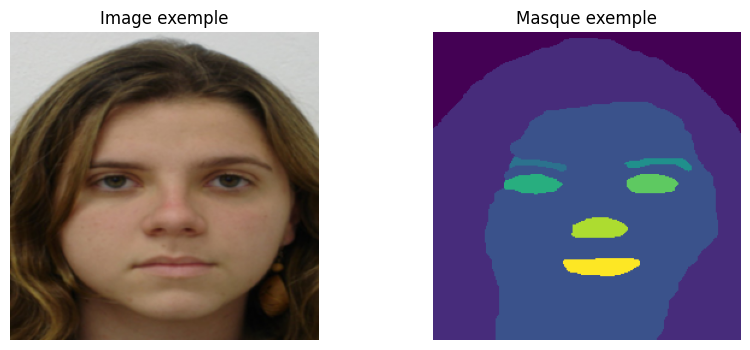

Classes présentes dans ce masque : [0 1 2 3 4 5 6 7 8]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 13. VISUALISATION D'UN EXEMPLE DU DATASET
# ==========================================================

sample_image, sample_mask = full_dataset[2] # Récupère la troisième image et son masque du dataset complet

plt.figure(figsize=(10, 4)) # Crée une nouvelle figure avec une taille spécifiée

plt.subplot(1, 2, 1) # Définit une grille de 1 ligne, 2 colonnes et sélectionne la première sous-figure
plt.imshow(sample_image.permute(1, 2, 0).numpy()) # Affiche l'image, en réarrangeant les dimensions de (C, H, W) à (H, W, C) pour matplotlib
plt.title("Image exemple") # Ajoute un titre à la sous-figure de l'image
plt.axis("off") # Cache les axes pour une meilleure visualisation de l'image

plt.subplot(1, 2, 2) # Sélectionne la deuxième sous-figure de la grille
plt.imshow(sample_mask.numpy()) # Affiche le masque de segmentation
plt.title("Masque exemple") # Ajoute un titre à la sous-figure du masque
plt.axis("off") # Cache les axes pour le masque

plt.show() # Affiche la figure avec les deux sous-figures

print("Classes présentes dans ce masque :", np.unique(sample_mask.numpy())) # Affiche les valeurs uniques des pixels du masque, représentant les différentes classes

**DÉFINITION DU BLOC DE CONVOLUTION DOUBLE**

On définit un bloc fondamental appelé DoubleConv, qui est le composant de base du modèle U-Net. Il est constitué de deux couches de convolution 3x3 consécutives, chacune suivie d'une normalisation par lots (BatchNorm2d) et d'une fonction d'activation ReLU. Cette structure permet au modèle d'extraire des caractéristiques de plus en plus complexes de l'image d'entrée, ce qui est essentiel pour la segmentation d'images.



In [ ]:
# ==========================================================
# 14. DÉFINITION DU BLOC DE CONVOLUTION DOUBLE
# ==========================================================

class DoubleConv(nn.Module):
    """
    Bloc standard du U-Net :
    deux convolutions 3x3 + BatchNorm + ReLU
    """

    def __init__(self, in_channels, out_channels): # Initialisation avec les canaux d'entrée et de sortie
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), # Première convolution 3x3
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1), # Deuxième convolution avec la même taille de sortie
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


**DÉFINITION DU MODÈLE U-NET**

Ce code définit l'architecture complète du modèle U-Net. Il est structuré en deux parties principales : un chemin descendant (encodeur) qui extrait les caractéristiques de l'image à travers des couches de convolutions et de pooling, et un chemin montant (décodeur) qui utilise ces caractéristiques pour reconstruire le masque de segmentation à la taille originale de l'image, en combinant les informations du chemin descendant. La couche finale produit la carte de prédiction pour les 9 classes de segmentation.



In [ ]:
# ==========================================================
# 15. DÉFINITION DU MODÈLE U-NET
# ==========================================================

class UNet(nn.Module):
    """
    U-Net plus profond que la version simple.
    """

    def __init__(self, in_channels=3, num_classes=9):
        super().__init__()

        # Chemin descendant (encodeur)
        self.down1 = DoubleConv(in_channels, 64) # Première étape de l'encodeur
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128) # Deuxième étape de l'encodeur
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256) # Troisième étape de l'encodeur
        self.pool3 = nn.MaxPool2d(2)

        # Goulot d'étranglement
        self.bottleneck = DoubleConv(256, 512) # Le point le plus profond du réseau

        # Chemin montant (décodeur)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2) # Déconvolution pour agrandir l'image
        self.conv_up3 = DoubleConv(512, 256) # Bloc double conv après concaténation

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(128, 64)

        # Couche finale : 9 cartes de classes
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1) # Couche de sortie pour la prédiction des classes

    def forward(self, x):
        # Encodeur
        d1 = self.down1(x)
        p1 = self.pool1(d1) # Réduction de la taille spatiale

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        # Bottleneck
        b = self.bottleneck(p3)

        # Décodeur
        u3 = self.up3(b)
        u3 = torch.cat([u3, d3], dim=1) # Concaténation avec la feature map correspondante de l'encodeur
        u3 = self.conv_up3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv_up2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv_up1(u1)

        # Sortie finale
        out = self.final_conv(u1) # La sortie est une carte de segmentation

        return out


Les principaux paramètres utilisés dans la définition du modèle U-Net sont les suivants :

in_channels=3: Ce paramètre spécifie le nombre de canaux d'entrée de l'image. Pour des images RGB, comme c'est le cas ici, la valeur est de 3 (rouge, vert, bleu).
num_classes=9: Ce paramètre indique le nombre total de classes de segmentation que le modèle doit prédire. Dans votre cas, il y a 9 classes différentes (y compris l'arrière-plan).
À l'intérieur du modèle, les paramètres des couches individuelles (comme kernel_size, padding, stride) sont fixés pour contrôler la taille des filtres de convolution, la manière dont les bords de l'image sont traités, et le pas de déplacement pour le downsampling/upsampling. Les nombres tels que 64, 128, 256, 512 représentent les nombres de canaux de sortie (out_channels) à chaque étape du réseau, augmentant dans l'encodeur pour capturer plus de caractéristiques et diminuant dans le décodeur lors de la reconstruction.



**INITIALISATION DU MODÈLE**

Constitue l'étape d'initialisation du modèle U-Net. Il crée une instance de la classe UNet que nous avons définie, en spécifiant 3 canaux d'entrée pour les images RGB et 9 classes de segmentation en sortie. L'appel .to(device) est crucial : il déplace le modèle vers le processeur sélectionné pour optimiser les performances de calcul.



In [ ]:
# ==========================================================
# 16. INITIALISATION DU MODÈLE
# ==========================================================

model = UNet(in_channels=3, num_classes=9).to(device)
print(model)


UNet(
  (down1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )


Le résultat affiché est une représentation textuelle de l'architecture complète de votre modèle U-Net. Il détaille chaque couche du réseau ainsi que les paramètres clés de ces couches. Cela permet de vérifier la structure du modèle elle qu'elle a été construite et initialisée, confirmant qu'elle correspond à la définition fournie.

**DÉFINITION DE LA FONCTION DE PERTE**

In [ ]:
# ==========================================================
# 17. DÉFINITION DE LA FONCTION DE PERTE
# ==========================================================
# On pondère davantage les petites classes comme les sourcils,
# les yeux, le nez, la bouche.

class_weights = torch.tensor(
    [0.5, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 1.5, 1.5], # Définition des poids pour chaque classe de segmentation
    dtype=torch.float32
).to(device) # Transfert des poids vers le même appareil que le modèle (CPU/GPU)

criterion = nn.CrossEntropyLoss(weight=class_weights) # Utilisation de CrossEntropyLoss avec les poids définis pour gérer le déséquilibre des classes


**OPTIMISEUR ET SCHEDULER**

On met en place l'optimiseur (Adam) et le scheduler de taux d'apprentissage (ReduceLROnPlateau). L'optimiseur Adam est responsable de l'ajustement des poids du modèle pour minimiser la fonction de perte. Le scheduler de taux d'apprentissage permet d'adapter dynamiquement le taux d'apprentissage pendant l'entraînement : si la perte de validation ne s'améliore pas après un certain nombre d'époques (patience), il réduit le taux d'apprentissage (factor) pour aider le modèle à converger plus finement.

In [ ]:
# ==========================================================
# 18. OPTIMISEUR ET SCHEDULER
# ==========================================================

optimizer = optim.Adam(model.parameters(), lr=1e-3) # Utilise l'optimiseur Adam avec un taux d'apprentissage initial de 0.001

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min", # Le mode est 'min' car nous surveillons une perte (validation loss)
    patience=3, # Réduit le LR si la perte de validation n'améliore pas après 3 époques
    factor=0.5 # Le taux d'apprentissage sera multiplié par 0.5 (divisé par 2) lors de la réduction
)


**FONCTIONS DE MÉTRIQUES**


On définit deux fonctions pour évaluer la performance du modèle de segmentation : pixel_accuracy calcule la proportion de pixels correctement classés, et mean_iou (Intersection sur Union) mesure la qualité de la superposition entre les prédictions et la vérité terrain pour chaque classe, puis en fait la moyenne.


In [ ]:
# ==========================================================
# 19. FONCTIONS DE MÉTRIQUES
# ==========================================================

def pixel_accuracy(preds, masks):
    """
    Calcule la Pixel Accuracy globale.
    """
    correct = (preds == masks).sum().item() # Compte le nombre total de pixels correctement prédits
    total = masks.numel() # Compte le nombre total de pixels dans les masques
    return correct / total # Retourne le ratio de pixels corrects sur le total


def mean_iou(preds, masks, num_classes=9):
    """
    Calcule l'IoU moyenne sur les classes présentes.
    """
    ious = [] # Liste pour stocker l'IoU de chaque classe

    preds = preds.view(-1) # Aplatit les prédictions en un vecteur 1D
    masks = masks.view(-1) # Aplatit les masques en un vecteur 1D

    for cls in range(num_classes):
        pred_inds = preds == cls # Masque booléen des pixels prédits comme étant de la classe 'cls'
        target_inds = masks == cls # Masque booléen des pixels réels de la classe 'cls'

        intersection = (pred_inds & target_inds).sum().item() # Calcule le nombre de pixels en intersection
        union = (pred_inds | target_inds).sum().item() # Calcule le nombre de pixels en union

        if union == 0: # Évite la division par zéro si la classe n'est pas présente dans le masque ou la prédiction
            continue

        ious.append(intersection / union) # Ajoute l'IoU calculé pour la classe actuelle

    if len(ious) == 0:
        return 0.0 # Retourne 0 si aucune classe n'a été trouvée avec des pixels valides

    return sum(ious) / len(ious) # Retourne l'IoU moyenne sur toutes les classes trouvées

Cette boucle d'entraînement gère le processus d'apprentissage du modèle sur num_epochs cycles. Chaque Epoch se compose d'une phase d'entraînement où le modèle ajuste ses poids pour minimiser la perte, suivie d'une phase de validation pour évaluer ses performances sur des données non vues. Le taux d'apprentissage est ajusté par un scheduler, et le meilleur modèle est sauvegardé en fonction de la perte de validation.

In [ ]:
# ==========================================================
# 20. BOUCLE D'ENTRAÎNEMENT
# ==========================================================

num_epochs = 40

train_losses = [] # Liste pour stocker les pertes d'entraînement par Epoch
val_losses = [] # Liste pour stocker les pertes de validation par Epoch

best_val_loss = float("inf") # Initialisation de la meilleure perte de validation à l'infini
best_model_path = "/content/best_unet_fasseg.pth" # Chemin pour sauvegarder le meilleur modèle

for epoch in range(num_epochs):

    # ------------------------------
    # Phase entraînement
    # ------------------------------
    model.train() # Met le modèle en mode entraînement
    running_train_loss = 0.0 # Initialisation de la perte cumulée pour l'Epoch d'entraînement

    for images, masks in train_loader:
        images = images.to(device, non_blocking=True) # Déplace les images vers le périphérique (CPU)
        masks = masks.to(device, non_blocking=True) # Déplace les masques vers le périphérique

        optimizer.zero_grad() # Réinitialise les gradients à zéro avant la rétropropagation

        outputs = model(images) # Passe avant : le modèle prédit les masques

        loss = criterion(outputs, masks) # Calcule la perte entre les prédictions et les vrais masques

        loss.backward() # Rétropropagation : calcule les gradients
        optimizer.step() # Met à jour les poids du modèle en utilisant l'optimiseur

        running_train_loss += loss.item() # Accumule la perte du lot actuel

    epoch_train_loss = running_train_loss / len(train_loader) # Calcule la perte moyenne d'entraînement pour l'Epoch
    train_losses.append(epoch_train_loss) # Ajoute la perte d'entraînement de l'Epoch à la liste

    # ------------------------------
    # Phase validation
    # ------------------------------
    model.eval() # Met le modèle en mode évaluation (désactive dropout, batchnorm, etc.)
    running_val_loss = 0.0 # Initialisation de la perte cumulée pour l'Epoch de validation
    val_acc_total = 0.0 # Initialisation de l'accuracy cumulée pour l'Epoch de validation
    val_iou_total = 0.0 # Initialisation de l'IoU cumulée pour l'Epoch de validation

    with torch.no_grad(): # Désactive le calcul des gradients pour la validation (économise de la mémoire et accélère)
        for images, masks in val_loader:
            images = images.to(device, non_blocking=True) # Déplace les images vers le périphérique
            masks = masks.to(device, non_blocking=True) # Déplace les masques vers le périphérique

            outputs = model(images) # Passe avant : le modèle prédit les masques
            loss = criterion(outputs, masks) # Calcule la perte de validation

            running_val_loss += loss.item() # Accumule la perte de validation du lot

            preds = torch.argmax(outputs, dim=1) # Obtient les prédictions finales (classe avec la plus grande probabilité)

            val_acc_total += pixel_accuracy(preds, masks) # Accumule la précision des pixels
            val_iou_total += mean_iou(preds, masks, num_classes=9) # Accumule l'IoU moyenne

    epoch_val_loss = running_val_loss / len(val_loader) # Calcule la perte moyenne de validation pour l'Epoch
    epoch_val_acc = val_acc_total / len(val_loader) # Calcule la précision moyenne des pixels de validation
    epoch_val_iou = val_iou_total / len(val_loader) # Calcule l'IoU moyenne de validation

    val_losses.append(epoch_val_loss) # Ajoute la perte de validation de l'Epoch à la liste

    # Mise à jour du scheduler
    scheduler.step(epoch_val_loss) # Met à jour le scheduler de taux d'apprentissage basé sur la perte de validation

    # Sauvegarde du meilleur modèle
    if epoch_val_loss < best_val_loss: # Si la perte de validation actuelle est meilleure que la meilleure enregistrée
        best_val_loss = epoch_val_loss # Met à jour la meilleure perte de validation
        torch.save(model.state_dict(), best_model_path) # Sauvegarde les poids du modèle
        print("Meilleur modèle sauvegardé.")

    current_lr = optimizer.param_groups[0]["lr"] # Récupère le taux d'apprentissage actuel

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Pixel Acc: {epoch_val_acc:.4f} | "
        f"Val mIoU: {epoch_val_iou:.4f} | "
        f"LR: {current_lr:.6f}"
    )


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Meilleur modèle sauvegardé.
Epoch [1/40] | Train Loss: 1.7784 | Val Loss: 2.1810 | Val Pixel Acc: 0.2991 | Val mIoU: 0.0388 | LR: 0.001000
Meilleur modèle sauvegardé.
Epoch [2/40] | Train Loss: 1.2585 | Val Loss: 1.9835 | Val Pixel Acc: 0.4489 | Val mIoU: 0.0499 | LR: 0.001000
Epoch [3/40] | Train Loss: 1.1273 | Val Loss: 4.8634 | Val Pixel Acc: 0.4489 | Val mIoU: 0.0499 | LR: 0.001000
Epoch [4/40] | Train Loss: 1.0341 | Val Loss: 3.0380 | Val Pixel Acc: 0.5157 | Val mIoU: 0.0733 | LR: 0.001000
Epoch [5/40] | Train Loss: 0.9446 | Val Loss: 4.6639 | Val Pixel Acc: 0.5214 | Val mIoU: 0.0753 | LR: 0.001000
Epoch [6/40] | Train Loss: 0.8455 | Val Loss: 3.4364 | Val Pixel Acc: 0.5434 | Val mIoU: 0.0833 | LR: 0.000500
Meilleur modèle sauvegardé.
Epoch [7/40] | Train Loss: 0.8165 | Val Loss: 1.6453 | Val Pixel Acc: 0.5718 | Val mIoU: 0.0936 | LR: 0.000500
Epoch [8/40] | Train Loss: 0.7607 | Val Loss: 1.6469 | Val Pixel Acc: 0.5832 | Val mIoU: 0.0980 | LR: 0.000500
Meilleur modèle sauvegardé.


Le résultat obtenu montre l'évolution des performances de votre modèle au fil des Epochs. Pour chaque Epoch, vous voyez la perte sur les données d'entraînement (Train Loss), la perte sur les données de validation (Val Loss), la précision des pixels de validation (Val Pixel Acc), l'IoU moyenne de validation (Val mIoU), et le taux d'apprentissage (LR).

**CHARGEMENT DU MEILLEUR MODÈLE**

In [ ]:
# ==========================================================
# 21. CHARGEMENT DU MEILLEUR MODÈLE
# ==========================================================

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("Meilleur modèle rechargé pour l'évaluation finale.")

Meilleur modèle rechargé pour l'évaluation finale.


**ÉVALUATION FINALE SUR LE JEU DE TEST**

Ce code évalue la performance finale du modèle sur le jeu de données de test. Il calcule la 'Pixel Accuracy' et le 'Mean IoU' du modèle sur les images de test, fournissant des métriques clés pour juger de la capacité du modèle à généraliser sur des données qu'il n'a jamais vues.



In [ ]:
# ==========================================================
# 22. ÉVALUATION FINALE SUR LE JEU DE TEST
# ==========================================================

test_acc_total = 0.0 # Initialise le cumul de la précision des pixels pour le test
test_iou_total = 0.0 # Initialise le cumul de l'IoU pour le test

with torch.no_grad(): # Désactive le calcul des gradients pour l'évaluation (optimisation de la mémoire et rapidité)
    for images, masks in test_loader: # Parcourt tous les lots d'images et de masques du DataLoader de test
        images = images.to(device, non_blocking=True) # Déplace les images vers le périphérique (CPU/GPU) sans bloquer le processus
        masks = masks.to(device, non_blocking=True) # Déplace les masques vers le périphérique sans bloquer le processus

        outputs = model(images) # Effectue la prédiction du modèle sur les images de test
        preds = torch.argmax(outputs, dim=1) # Obtient la classe prédite pour chaque pixel en prenant l'argmax le long de la dimension des canaux

        test_acc_total += pixel_accuracy(preds, masks) # Accumule la précision des pixels pour le lot actuel
        test_iou_total += mean_iou(preds, masks, num_classes=9) # Accumule l'IoU moyenne pour le lot actuel

final_test_pixel_acc = test_acc_total / len(test_loader) # Calcule la précision des pixels finale en divisant le total par le nombre de lots
final_test_miou = test_iou_total / len(test_loader) # Calcule l'IoU moyenne finale en divisant le total par le nombre de lots

print("\n===== RÉSULTATS FINAUX SUR LE TEST =====") # Affiche un séparateur pour les résultats
print(f"Pixel Accuracy test : {final_test_pixel_acc:.4f}") # Affiche la précision des pixels finale formatée
print(f"Mean IoU test       : {final_test_miou:.4f}") # Affiche l'IoU moyenne finale formatée



===== RÉSULTATS FINAUX SUR LE TEST =====
Pixel Accuracy test : 0.9088
Mean IoU test       : 0.4912


**COURBES DE PERTE**

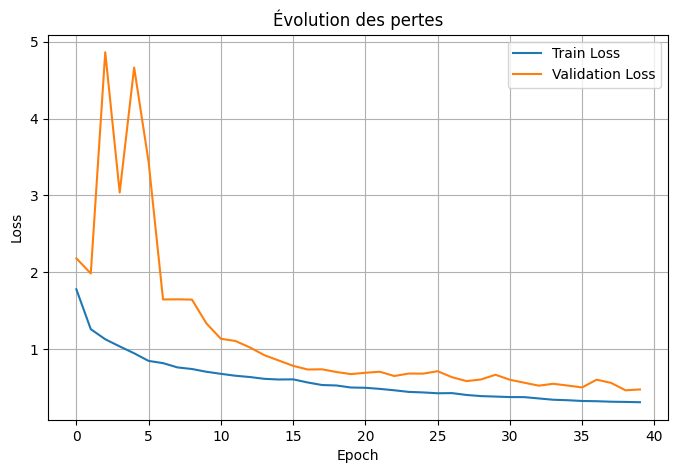

In [ ]:
# ==========================================================
# 23. COURBES DE PERTE
# ==========================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Évolution des pertes")
plt.xlabel("Epoch") # Définit le libellé de l'axe des x
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


La courbe affichée représente l'évolution de la perte (Loss) du modèle au cours des Epochs d'entraînement. La 'Train Loss' (ligne bleue) montre à quel point le modèle apprend bien sur les données qu'il a déjà vues. La 'Validation Loss' (ligne orange) est cruciale car elle indique la capacité du modèle à généraliser sur des données qu'il n'a jamais rencontrées. Idéalement, les deux courbes devraient diminuer de manière stable, et la perte de validation ne devrait pas commencer à augmenter significativement, ce qui pourrait indiquer un surapprentissage.

**VISUALISATION QUALITATIVE SUR UNE IMAGE DE TEST**

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


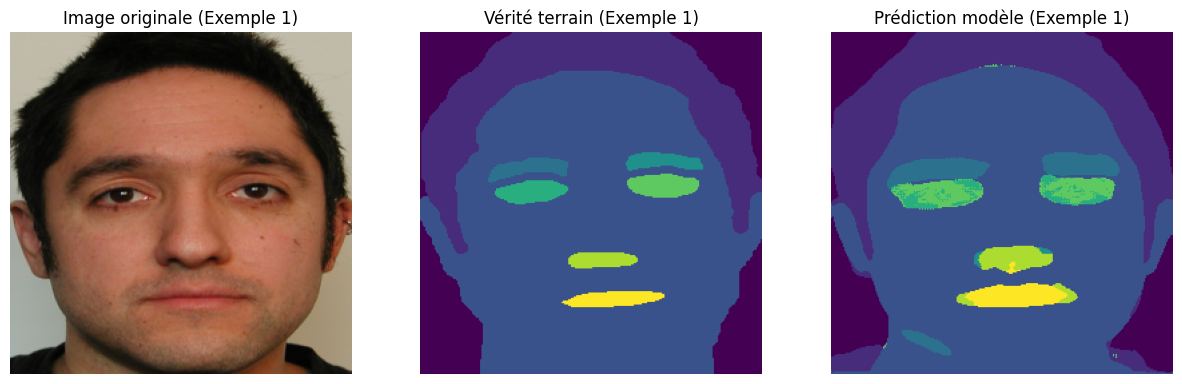

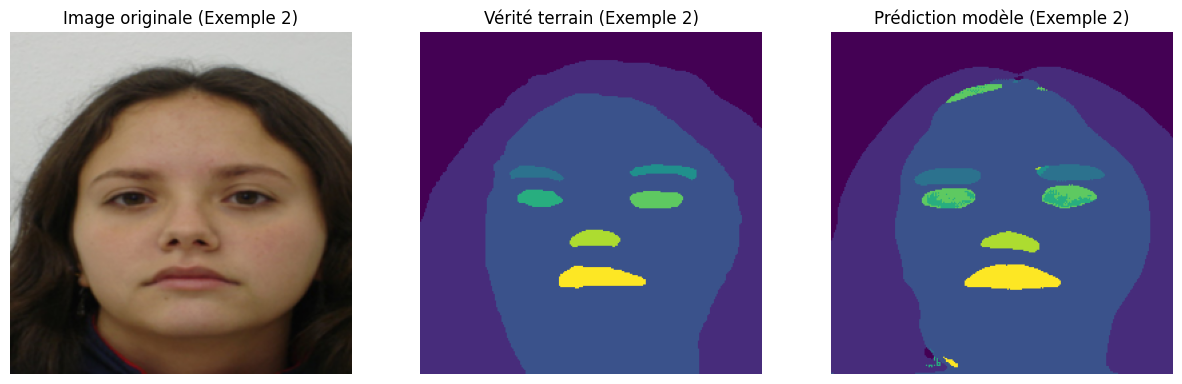

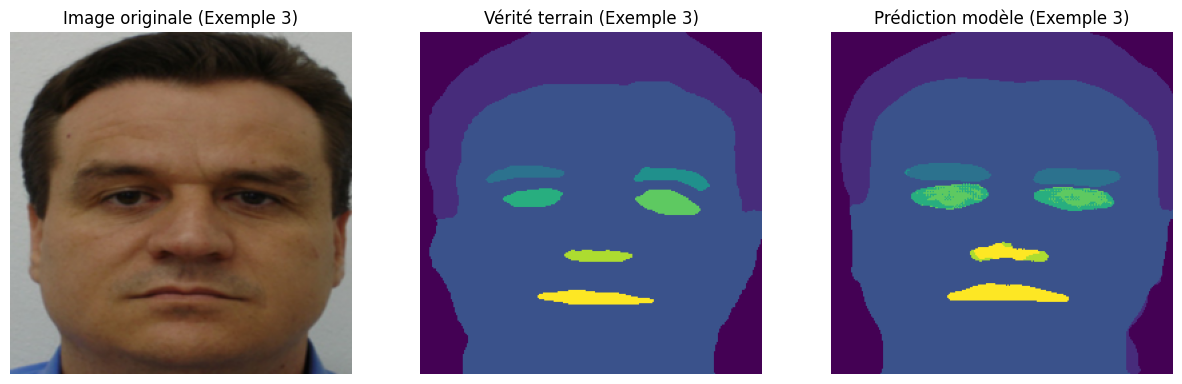

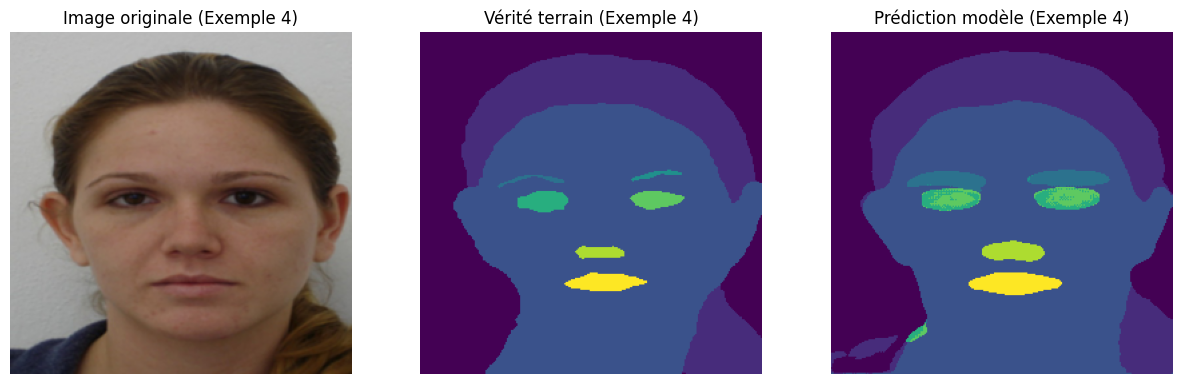

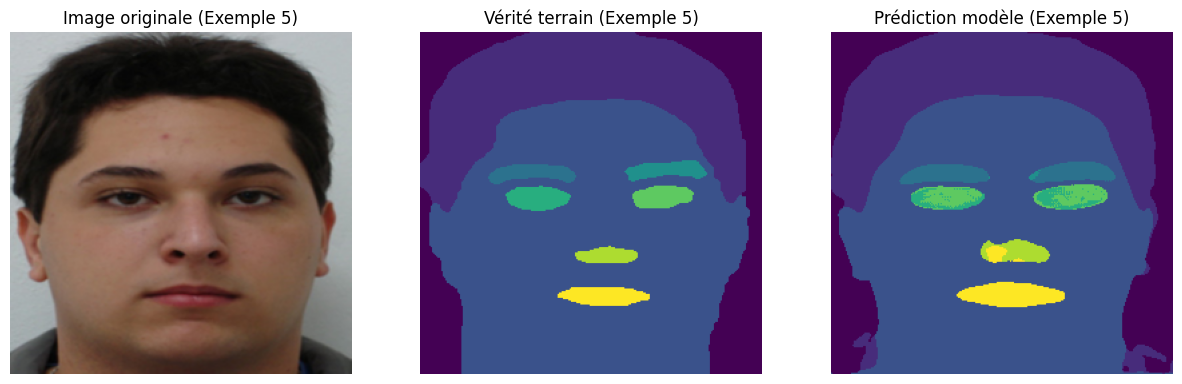

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ==========================================================
# 24. VISUALISATION QUALITATIVE SUR UNE IMAGE DE TEST
# ==========================================================

model.eval()
num_visualizations = 0

with torch.no_grad():
    for i, (images, masks) in enumerate(test_loader):
        if num_visualizations >= 5:
            break

        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        # Take the first image/mask/prediction from the batch (batch size is 1 for test_loader)
        image_np = images[0].cpu().permute(1, 2, 0).numpy()
        mask_np = masks[0].cpu().numpy()
        pred_np = preds[0].cpu().numpy()

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(image_np)
        plt.title(f"Image originale (Exemple {num_visualizations + 1})")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask_np)
        plt.title(f"Vérité terrain (Exemple {num_visualizations + 1})")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_np)
        plt.title(f"Prédiction modèle (Exemple {num_visualizations + 1})")
        plt.axis("off")

        plt.show()
        num_visualizations += 1

# The last image_np, mask_np, pred_np from the loop will be stored
# These will be used by the saving cell (cell cnDmGpumc1FP) if it runs after this cell.
# If you need to save all 5 visualizations, the saving logic in cell cnDmGpumc1FP would need further modification.

Le Modèle prédit relativement bien

In [ ]:
# ==========================================================
# 25. SAUVEGARDE DES RÉSULTATS DANS UN DOSSIER
# ==========================================================

results_dir = "/content/fasseg_results"
os.makedirs(results_dir, exist_ok=True)

# Sauvegarde des courbes
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Évolution des pertes")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir, "loss_curves.png"))
plt.close()

# Sauvegarde de la visualisation qualitative
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Image originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np)
plt.title("Vérité terrain")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_np)
plt.title("Prédiction modèle")
plt.axis("off")

plt.savefig(os.path.join(results_dir, "qualitative_result.png"))
plt.close()

# Sauvegarde des métriques dans un fichier texte
with open(os.path.join(results_dir, "metrics.txt"), "w", encoding="utf-8") as f:
    f.write("Résultats FASSEG - U-Net\n")
    f.write("========================\n")
    f.write(f"Pixel Accuracy test : {final_test_pixel_acc:.4f}\n")
    f.write(f"Mean IoU test       : {final_test_miou:.4f}\n")

print(f"Résultats sauvegardés dans : {results_dir}")


Résultats sauvegardés dans : /content/fasseg_results
